# Lab 1.1 — Price, cost and profit

*Prerequisite: run `01_data_foundation.ipynb` first.*

This is the arithmetic every other notebook stands on. It is not hard
arithmetic. It is arithmetic that is **easy to do and easy to do wrongly**,
and the wrong versions are quoted confidently in meetings every day.

By the end you will be able to answer, from data:

- what one order actually earns us, after everything;
- why the online channel needs a *higher* margin than a branch to break even,
  and why the biggest number in the branch cost stack is not ours to control;
- how many extra sales a 10% discount must generate merely to stand still;
- where our list price leaks away before it becomes profit;
- why profit moved between last year and this one — price, volume, or mix.

---

## What a price is

A price is not a number attached to a product. A price is **the point at
which two different valuations meet**: the most the customer will part with,
and the least you will accept.

```
        your cost                       customer's willingness to pay
            |------------ the bargaining range ------------|
                            ^
                        the price
```

- Below your cost, you shouldn't sell.
- Above their willingness to pay, they won't buy.
- Everything in between is negotiation, positioning, competition and nerve.

Two consequences follow immediately, and they are the foundation of
professional pricing:

**1. Cost sets the floor, not the price.** "Cost plus 30%" is a way of
picking a number inside the range without thinking about the customer. It is
popular because it is defensible in a meeting, not because it is right.

**2. Value sets the ceiling, and value is personal.** The traveller at
Heathrow with ninety minutes before a flight values euros differently from
the same person planning a trip six weeks earlier. Same product, same cost,
different ceiling. That is not exploitation in itself — it is the reason
segmentation exists ([lab 4.1](../04_satisfy_the_regulator/lab_01_segmentation_and_fairness.ipynb) covers where the ethical and legal lines
sit).

## The three prices

Almost every commercial argument about "our price" is really two people
talking about different prices.

| Name | What it means | In our data |
|---|---|---|
| **List price** | What the rate board says | `fct_price_board.our_margin_pp` |
| **Quoted price** | What this customer was offered, after promotions and tests | `fct_quotes.quoted_margin_pp` |
| **Realised price** | What we actually earned, averaged over the business we won | value-weighted `fct_transactions.margin_pp` |

They are never equal, and the gaps between them are where the money hides.
We will measure all three later in this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from toolkit import C, INK, MUT, SUB, load, money, pct, style, tidy

style()

quotes = load("fct_quotes")
txn = load("fct_transactions")
sites = load("dim_sites")
products = load("dim_products")
cost_stack = load("dim_cost_stack")

txn["year"] = txn["date"].dt.year
print(f"{len(quotes):,} quotes, {len(txn):,} orders, "
      f"{txn['date'].min():%b %Y} to {txn['date'].max():%b %Y}")

309,546 quotes, 177,656 orders, Jan 2023 to Dec 2025


## Costs: five words that are not synonyms

Cost is where most pricing errors are born, because "cost" in ordinary
speech means five different things.

| Term | Definition | Meridian example | Does it affect the best price? |
|---|---|---|---|
| **Variable cost** | Changes with each unit sold | Funding, card fee, handling, courier | **Yes** — directly |
| **Fixed cost** | Unchanged by the next sale | Airport rent, IT, compliance, branch equipment | **No** — see below |
| **Marginal cost** | The cost of *one more* sale | ≈ the variable cost of that order | **Yes** — it is the floor |
| **Sunk cost** | Already spent, unrecoverable | The £250k kiosk refit in 2021 | **No** — and never |
| **Opportunity cost** | The best thing you gave up | Notes sitting in one branch safe while another sells out | Yes, when capacity binds |

### Why fixed costs do not set the price

This is the single most counter-intuitive idea in pricing, and it is worth
being stubborn about.

An airport kiosk pays its rent whether it sells one order or ten thousand. So when you ask *"what price maximises profit?"*, the rent is the
same number under every answer. It cancels. The price that maximises
contribution maximises profit, full stop.

That does **not** make fixed costs irrelevant. They decide a different
question: *should this site exist at all?* Those are two separate decisions
and merging them produces the classic death spiral — a site looks
unprofitable after overhead allocation, so prices are raised to "cover
overhead", so volume falls, so overhead per unit rises, so prices are raised
again.

> **The rule.** Fixed costs decide *whether to play*. Variable costs and
> customer behaviour decide *what to charge*.

### Cost to serve is not a company-level number

Our cost stack shows the point in miniature.

In [2]:
print(cost_stack.to_string(index=False))

       cost_line                                                               description behaviour                basis                             typical_level                                                                               note
         funding                                       Wholesale cost of sourcing currency  variable     % of order value                                    ~0.22%                                      moves daily; see fct_calendar.funding_cost_bp
     payment_fee                                        Card acquiring / cash handling fee  variable     % of order value                0.90% online, 0.20% branch                                       why online margin cannot simply match branch
        handling                                             Counting, packing, AML checks  variable          £ per order £1.10 cash, £2.40 card, +£0.90 collection                                                           per order, not per pound
        deli

## The unit economics of one order

Let's take the most important number in the business apart: what a single
order earns, by site.

Watch the online column.

In [3]:
unit = (txn.groupby(["channel", "fulfilment"])
        .agg(orders=("txn_id", "count"),
             order_value=("order_value_gbp", "mean"),
             revenue=("gross_revenue_gbp", "mean"),
             funding=("funding_cost_gbp", "mean"),
             payment=("payment_fee_gbp", "mean"),
             handling=("handling_cost_gbp", "mean"),
             delivery=("delivery_cost_gbp", "mean"),
             commission=("commission_gbp", "mean"),
             variable=("variable_cost_gbp", "mean"),
             contribution=("contribution_gbp", "mean")))

unit["contribution_%_of_revenue"] = (unit["contribution"] / unit["revenue"]).round(3)
unit["variable_cost_in_pp"] = (100 * unit["variable"] / unit["order_value"]).round(2)
print(unit[["orders", "order_value", "revenue", "funding", "payment", "handling",
            "delivery", "commission", "variable", "contribution",
            "contribution_%_of_revenue", "variable_cost_in_pp"]].round(2).to_string())

                       orders  order_value  revenue  funding  payment  handling  delivery  commission  variable  contribution  contribution_%_of_revenue  variable_cost_in_pp
channel fulfilment                                                                                                                                                           
airport branch          34053       348.40    22.10     0.76     0.70      1.22      0.00        1.92      4.59         17.51                       0.79                 1.32
branch  branch          78466       503.55    18.02     1.10     1.01      1.40      0.00        2.77      6.27         11.75                       0.65                 1.25
online  click_collect   25022       486.22    13.98     1.06     4.38      2.30      0.00        1.36      9.09          4.89                       0.35                 1.87
        delivery        40115       534.76    15.24     1.16     4.81      1.39      3.49        0.00     10.85          4.39     

Read the last column again: **the variable cost of serving an order,
expressed in margin points.**

Four routes to market, four different cost structures — and they are much
closer together than anybody's intuition says:

- A **branch** order costs about 1.25pp, and the single largest piece is not
  anything the operation controls: it is the **commission paid to the host
  retail network**, roughly 0.55% of everything sold over a counter.
- An **online delivery** order costs about 2.05pp — no commission, but 0.9%
  card acquiring plus a £4.50 insured courier.
- **Click & collect** sits in between at about 1.9pp: it dodges the courier
  and then pays the branch instead.
- The **airport** is cheapest to serve (about 1.3pp) and dearest to charge.

Two lessons fall out of that table, and both matter more than the numbers.

**Do not assume which channel is cheaper.** "Online has no rent" is a
statement about *fixed* costs, which — as we are about to see — have nothing
to do with the optimal price. On the variable costs that *do* set the price,
online here is the dearest of the three.

**The biggest number in a cost stack often belongs to someone else.**
Commission is negotiated, not engineered. A 10bp improvement in the network
deal is worth more to this business than almost any rate change the pricing
desk is allowed to make — and no amount of elasticity modelling will find
it, because it is not in the pricing team's spreadsheet.

> **A habit worth building.** Whenever someone quotes a margin, ask "gross
> of what?" Our online gross margin is about 2.9pp and its *contribution*
> margin is about 0.9pp. Both are true. Only one of them pays the rent.

## Margin, markup, and the vocabulary that trips people up

Four definitions, one worked example, and then a table you can check
yourself against.

Take an order of **£500** of euros at a **4.0pp** margin, costing us
**£3.50** to serve.

| Quantity | Formula | Here |
|---|---|---|
| Turnover | what the customer hands over | £500.00 |
| Gross revenue | turnover × margin ÷ 100 | £20.00 |
| Variable cost | funding + fee + handling + delivery | £3.50 |
| **Contribution** | revenue − variable cost | **£16.50** |
| Contribution margin (% of revenue) | contribution ÷ revenue | 82.5% |
| Contribution in points | contribution ÷ turnover × 100 | 3.30pp |

**Margin vs markup.** Margin is profit as a share of *price*; markup is
profit as a share of *cost*. They are not the same number and confusing them
is the most common arithmetic error in commercial life:

```
margin = (price − cost) / price          markup = (price − cost) / cost
```

Buy at £70, sell at £100: margin 30%, markup 42.9%. A "50% markup" is a
33.3% margin. If someone says "we need 40% margin" and the buyer applies a
40% markup, the business is 7 points short and nobody notices for a quarter.

**Percentages vs percentage points vs basis points.** Moving a margin from
3.5% to 4.0% is a rise of **0.5 percentage points**, which is **50 basis
points**, which is a **14.3% increase** in the margin. All three phrasings
are correct; only one of them means anything without context. Pricing desks
default to bp for exactly this reason.

In [4]:
def margin_from_markup(markup):
    return markup / (1 + markup)


def markup_from_margin(margin):
    return margin / (1 - margin)


demo = pd.DataFrame({"markup": [0.10, 0.25, 0.333, 0.50, 1.00, 2.00]})
demo["equivalent margin"] = demo["markup"].apply(margin_from_markup).round(4)
demo["margin"] = [0.10, 0.20, 0.25, 0.333, 0.50, 0.667]
demo["equivalent markup"] = demo["margin"].apply(markup_from_margin).round(4)
print(demo.to_string(index=False))
print("\nA 50% markup is a 33.3% margin. A 50% margin needs a 100% markup.")

 markup  equivalent margin  margin  equivalent markup
  0.100             0.0909   0.100             0.1111
  0.250             0.2000   0.200             0.2500
  0.333             0.2498   0.250             0.3333
  0.500             0.3333   0.333             0.4993
  1.000             0.5000   0.500             1.0000
  2.000             0.6667   0.667             2.0030

A 50% markup is a 33.3% margin. A 50% margin needs a 100% markup.


## Contribution, break-even, and whether a site should exist

**Contribution** is what one sale contributes towards fixed costs and
profit. Add up all the contribution, subtract the fixed costs, and you have
profit:

```
profit = (contribution per order × orders) − fixed costs
```

Set profit to zero and you get the **break-even volume**:

```
break-even orders = fixed costs ÷ contribution per order
```

That is the whole of break-even analysis. Now apply it to the six sites and
a question the board actually asks: *should we close Glasgow?*

In [5]:
CENTRAL_OVERHEAD_MONTH = 12000

y25 = txn[txn["year"] == 2025]
site_pnl = (y25.groupby("site_id")
            .agg(orders=("txn_id", "count"),
                 turnover=("order_value_gbp", "sum"),
                 revenue=("gross_revenue_gbp", "sum"),
                 contribution=("contribution_gbp", "sum"))
            .join(sites.set_index("site_id")[["site_name", "channel", "fixed_cost_month_gbp"]]))

site_pnl["fixed_cost_year"] = site_pnl["fixed_cost_month_gbp"] * 12
site_pnl["site_profit"] = site_pnl["contribution"] - site_pnl["fixed_cost_year"]
site_pnl["contribution_per_order"] = site_pnl["contribution"] / site_pnl["orders"]
site_pnl["breakeven_orders"] = (site_pnl["fixed_cost_year"] / site_pnl["contribution_per_order"]).round(0)

channel_pnl = site_pnl.groupby("channel").agg(
    sites=("orders", "size"), orders=("orders", "sum"), turnover=("turnover", "sum"),
    revenue=("revenue", "sum"), contribution=("contribution", "sum"),
    fixed=("fixed_cost_year", "sum"))
channel_pnl["channel_profit"] = channel_pnl["contribution"] - channel_pnl["fixed"]
channel_pnl["contribution_per_order"] = channel_pnl["contribution"] / channel_pnl["orders"]
print("BY CHANNEL (2025)\n")
print(channel_pnl.round(1).to_string())

print("\nTHE FIVE WEAKEST SITES\n")
weakest = site_pnl.nsmallest(5, "site_profit")
print(weakest[["site_name", "orders", "contribution", "fixed_cost_year",
               "site_profit", "contribution_per_order", "breakeven_orders"]].round(1).to_string())

group_contribution = site_pnl["contribution"].sum()
group_fixed = site_pnl["fixed_cost_year"].sum() + CENTRAL_OVERHEAD_MONTH * 12
print(f"\ngroup contribution {money(group_contribution)}"
      f"   fixed costs {money(group_fixed)}"
      f"   operating profit {money(group_contribution - group_fixed)}")
print(f"sites below break-even: {(site_pnl['site_profit'] < 0).sum()} of {len(site_pnl)}")

BY CHANNEL (2025)



         sites  orders    turnover   revenue  contribution   fixed  channel_profit  contribution_per_order
channel                                                                                                   
airport      2   12042   4204320.0  263524.0      208882.9  108000        100882.9                    17.3
branch      24   26746  13497800.0  471321.3      305648.8  180000        125648.8                    11.4
online       1   22180  11474340.0  322270.1       98104.7   72000         26104.7                     4.4

THE FIVE WEAKEST SITES



                            site_name  orders  contribution  fixed_cost_year  site_profit  contribution_per_order  breakeven_orders
site_id                                                                                                                            
B082                Wales Retail park     543        5912.4             6600       -687.6                    10.9             606.0
B072           North East Retail park     561        6286.1             6600       -313.9                    11.2             589.0
B122     Northern Ireland Retail park     543        6684.9             6600         84.9                    12.3             536.0
B032           South West Retail park     747        7736.7             6600       1136.7                    10.4             637.0
B121     Northern Ireland City centre     890       10370.3             8400       1970.3                    11.7             721.0

group contribution £612,636   fixed costs £504,000   operating profit £108,

### Reading that table like a commercial manager

**Turnover is a vanity metric.** The online channel turns over more than any
other and contributes the least per quote of the three. If your dashboard
leads with turnover, your business will optimise for the wrong thing. Lead
with contribution.

**The branch estate looks cheap because somebody else owns it.** Twenty-four
branches carry a trivial fixed cost between them, because the host network
provides the shops and the staff — and takes commission instead. That is a
real strategic position, not an accounting quirk: the estate is *variable
cost heavy and fixed cost light*, which makes it resilient in a downturn and
expensive in a boom. The opposite of the airport kiosks.

**Some sites still lose money.** For each one, the reasoning a good pricing
manager brings:

1. **Is the fixed cost actually avoidable?** If a contract has years to run,
   closing saves less than the accounts imply. Compare against *avoidable*
   fixed cost, not accounting fixed cost.
2. **Where does the volume go?** Customers who switch to a nearby branch or
   online are contribution that *moves* rather than disappears — and this
   business now has the channel-choice data to estimate how much.
3. **Is it a pricing problem or a demand problem?** A site with a high
   margin and low conversion has been quietly closing the gap on its own
   P&L by raising price, which works right up until it doesn't.
4. **What is the option value?** A region with no other presence is worth
   more than its P&L line.

None of those are statistics questions. They are the questions that make the
statistics worth doing, and a pricing analyst who brings the number without
the questions gets overruled by whoever brings the story.

## The discount break-even: the most useful formula in commerce

Someone will propose a discount this week. Here is how to answer in ten
seconds.

If you cut price by **d** points and your contribution margin is **CM**
points, then to hold contribution flat you need volume to rise by

```
required volume uplift  =  d / (CM − d)
```

Why: contribution per order falls from CM to (CM − d), so you need enough
extra orders to make CM − d go as far as CM did. Our overall contribution
margin is about 2.5pp of turnover, so:

| Discount | New contribution | Volume needed just to stand still |
|---|---|---|
| 0.10pp | 2.40pp | +4.2% |
| 0.25pp | 2.25pp | +11.1% |
| 0.50pp | 2.00pp | +25.0% |
| 1.00pp | 1.50pp | +66.7% |

Note the shape: the requirement explodes as the discount approaches your
margin. **The thinner your margin, the more lethal a discount is.** A
business running 2.5pp of contribution cannot buy its way to volume; a
business running 60% contribution margins can.

Now flip it round, because this is the argument that wins meetings: the same
formula run backwards says how much volume you can *afford to lose* on a
price increase.

```
tolerable volume loss  =  d / (CM + d)
```

Raise price by 0.25pp on a 2.5pp contribution margin and you can lose 9.1%
of your volume and still be level. Compare that with the elasticity you
measure in [lab 1.2](lab_02_demand_and_elasticity.ipynb) — that comparison is the entire price decision.

In [6]:
cm_pp = 100 * txn["contribution_gbp"].sum() / txn["order_value_gbp"].sum()

rows = []
for d in [0.10, 0.25, 0.50, 1.00]:
    rows.append({"move_pp": d,
                 "cut: volume needed to stand still": f"+{d / (cm_pp - d):.1%}",
                 "rise: volume you can afford to lose": f"-{d / (cm_pp + d):.1%}"})
print(f"contribution margin = {cm_pp:.2f}pp of turnover\n")
print(pd.DataFrame(rows).to_string(index=False))

contribution margin = 2.14pp of turnover

 move_pp cut: volume needed to stand still rise: volume you can afford to lose
    0.10                             +4.9%                               -4.5%
    0.25                            +13.2%                              -10.5%
    0.50                            +30.5%                              -19.0%
    1.00                            +88.0%                              -31.9%


## The price waterfall: where list price leaks away

The **waterfall** walks from the price on the board to the profit in the
bank, one deduction at a time. It is the single most useful diagram in
commercial pricing, because each step is owned by someone different and
therefore fixable by someone different.

Our steps:

1. **Board (list) margin** — what the rate card says, weighted by the money
   it applied to.
2. **Size tiers** — the published better rate on orders over £1,000 and
   £2,500. A deliberate policy, not a leak — but it belongs on the
   waterfall, because it is money the board rate never sees.
3. **Quoted margin** — after promotions and price tests. Owned by trading.
3. **Realised margin** — what we actually earned. The gap is not a discount;
   it is *selection*: the orders that convert are not a random sample of the
   orders we quote, and larger orders shop harder.
4. **Non-rate revenue** — the £4.95 card issuance fee. Waterfalls run in
   both directions; fees, delivery charges and add-ons push the line back
   up, and forgetting them is how "we lose money on every order" myths get
   started.
5. **Cost to serve** — funding, payment fees, handling, delivery, each
   removed in points.
6. **Contribution margin** — what is left.

Before running it, guess: how much of the 3.65pp on the board survives to
contribution?

In [7]:
value_all = quotes["order_value_gbp"]
value_won = txn["order_value_gbp"]

board_pp = (value_all * quotes["our_margin_pp"]).sum() / value_all.sum()
tiered_pp = (value_all * (quotes["our_margin_pp"] + quotes["size_tier_pp"])).sum() / value_all.sum()
quoted_pp = (value_all * quotes["quoted_margin_pp"]).sum() / value_all.sum()
realised_pp = (value_won * txn["margin_pp"]).sum() / value_won.sum()

card_fee_pp = 100 * (txn["product_id"].eq("TRAVEL_CARD")
                     * products.set_index("product_id").loc["TRAVEL_CARD", "card_fee_gbp"]).sum() / value_won.sum()

cost_pp = {name: -100 * txn[col].sum() / value_won.sum() for name, col in
           [("funding", "funding_cost_gbp"), ("payment fees", "payment_fee_gbp"),
            ("handling", "handling_cost_gbp"), ("delivery", "delivery_cost_gbp"),
            ("network commission", "commission_gbp")]}

steps = [("board (list) margin", board_pp, "start"),
         ("size tiers", tiered_pp - board_pp, "step"),
         ("promotions & tests", quoted_pp - tiered_pp, "step"),
         ("selection / mix", realised_pp - quoted_pp, "step"),
         ("card fees", card_fee_pp, "step")]
steps += [(k, v, "step") for k, v in cost_pp.items()]
steps += [("contribution margin", realised_pp + card_fee_pp + sum(cost_pp.values()), "end")]

wf = pd.DataFrame(steps, columns=["step", "pp", "kind"])
wf["cumulative"] = np.where(wf["kind"] == "step", np.nan, wf["pp"])
running = board_pp
for i, row in wf.iterrows():
    if row["kind"] == "step":
        running += row["pp"]
        wf.loc[i, "cumulative"] = running
print(wf.round(3).to_string(index=False))
print(f"\n{board_pp:.2f}pp on the board becomes {wf['cumulative'].iloc[-1]:.2f}pp of contribution "
      f"- {100 * (1 - wf['cumulative'].iloc[-1] / board_pp):.0f}% of the headline never reaches the bottom line.")

               step     pp  kind  cumulative
board (list) margin  3.604 start       3.604
         size tiers -0.052  step       3.551
 promotions & tests  0.003  step       3.554
    selection / mix -0.083  step       3.471
          card fees  0.209  step       3.680
            funding -0.218  step       3.462
       payment fees -0.477  step       2.985
           handling -0.311  step       2.674
           delivery -0.164  step       2.509
 network commission -0.372  step       2.137
contribution margin  2.137   end       2.137



3.60pp on the board becomes 2.14pp of contribution - 41% of the headline never reaches the bottom line.


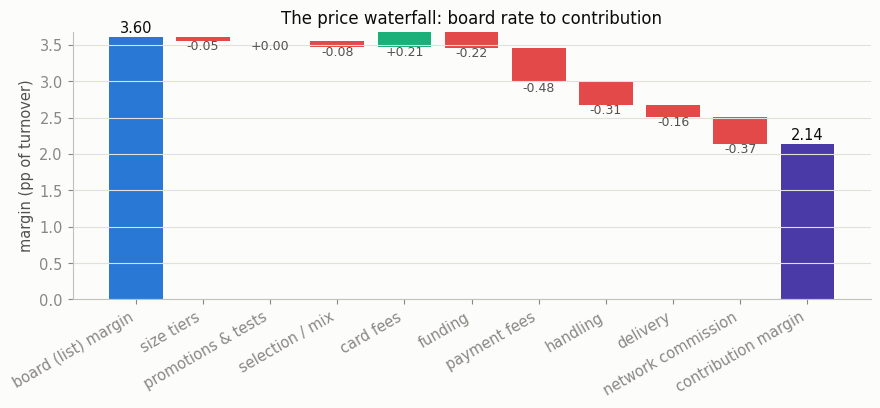

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.2))
bottom = 0.0
for i, row in wf.iterrows():
    if row["kind"] == "start":
        ax.bar(i, row["pp"], color=C[0]); bottom = row["pp"]
        ax.text(i, row["pp"] + 0.06, f"{row['pp']:.2f}", ha="center", color=INK)
    elif row["kind"] == "step":
        colour = C[1] if row["pp"] > 0 else C[5]
        ax.bar(i, row["pp"], bottom=bottom, color=colour)
        ax.text(i, bottom + min(row["pp"], 0) - 0.12, f"{row['pp']:+.2f}", ha="center", color=SUB, fontsize=9)
        bottom += row["pp"]
    else:
        ax.bar(i, row["pp"], color=C[4])
        ax.text(i, row["pp"] + 0.06, f"{row['pp']:.2f}", ha="center", color=INK)

ax.set_xticks(range(len(wf)))
ax.set_xticklabels(wf["step"], rotation=30, ha="right")
ax.set_ylabel("margin (pp of turnover)")
ax.set_title("The price waterfall: board rate to contribution")
tidy(ax)
plt.tight_layout()
plt.show()

### What each step tells you to do

- **Size tiers** is a *chosen* step. It is the price of a policy that says
  large orders get a better rate — and [lab 4.1](../04_satisfy_the_regulator/lab_01_segmentation_and_fairness.ipynb) asks whether that policy
  earns its keep.
- **Promotions & tests** is tiny here because our promotion ran on one
  product in four regions. In a retailer this step is often −10pp or worse,
  and it is the fastest money in pricing: half of most promotional spend
  goes to customers who would have bought anyway ([lab 2.5](../02_prove_the_change/lab_05_causal_inference.ipynb) measures
  exactly that).
- **Selection / mix** is not a leak you can plug by telling someone off. It
  is customers behaving rationally — the orders that convert are quoted the
  keenest rates, and the largest orders shop hardest.
- **Payment fees and network commission** are the two largest deductions,
  and *nobody in the pricing team controls either of them*. This is normal
  and important: the biggest number on your waterfall often belongs to
  another department. Finding it is worth more than another week of
  modelling — a 10bp improvement on either contract is worth more here than
  most rate changes the desk is allowed to make.

## Why did profit move? The price–volume–mix bridge

Revenue went up £82k between 2024 and 2025. The board wants to know whether
that is a pricing win, a demand win, or an accident. Three effects, one
exact decomposition:

- **Volume** — we sold more, at last year's average rate.
- **Price** — we charged a different rate on the business we did.
- **Mix** — the *composition* changed: more of the business came from
  cheaper or dearer parts of the portfolio.

```
volume = (Q1 − Q0) × m0
mix    = Σ Q1ᵢ × m0ᵢ  −  Q1 × m0
price  = Σ Q1ᵢ × (m1ᵢ − m0ᵢ)
```

where Q is turnover, m is margin rate, subscript i is each site × product,
0 is last year and 1 is this year. Those three add to the revenue change
exactly — no residual, no fudge.

Mix is the one people forget, and it is the one that produces the meeting
where everybody is confused: *every single site raised its rate, and the
group's average rate fell.* That is not a paradox and not an error; it is
mix. ([Lab 4.1](../04_satisfy_the_regulator/lab_01_segmentation_and_fairness.ipynb) shows the same arithmetic doing real damage under the name
Simpson's paradox.)

In [9]:
cell = (txn.groupby(["year", "site_id", "product_id"])
        .agg(Q=("order_value_gbp", "sum"), R=("gross_revenue_gbp", "sum")))

prev, curr = cell.xs(2024), cell.xs(2025)
m0_total = prev["R"].sum() / prev["Q"].sum()
m0_cell = (prev["R"] / prev["Q"]).reindex(curr.index)
m1_cell = curr["R"] / curr["Q"]

volume_effect = (curr["Q"].sum() - prev["Q"].sum()) * m0_total
mix_effect = (curr["Q"] * m0_cell).sum() - curr["Q"].sum() * m0_total
price_effect = (curr["Q"] * (m1_cell - m0_cell)).sum()

bridge = pd.Series({
    "2024 revenue": prev["R"].sum(),
    "volume": volume_effect,
    "mix": mix_effect,
    "price": price_effect,
    "2025 revenue": curr["R"].sum(),
})
print(bridge.round(0).to_string())
print(f"\ncheck: {volume_effect + mix_effect + price_effect:,.0f} "
      f"vs actual change {curr['R'].sum() - prev['R'].sum():,.0f}")
print(f"\naverage margin rate: {100 * m0_total:.3f}pp -> {100 * m1_cell.mul(curr['Q']).sum() / curr['Q'].sum():.3f}pp")

2024 revenue    1038242.0
volume            47182.0
mix                3163.0
price            -31472.0
2025 revenue    1057115.0

check: 18,873 vs actual change 18,873

average margin rate: 3.720pp -> 3.623pp


The bridge says: **we grew by selling more, and gave away about £13k on
rate while doing it.**

That single sentence is the deliverable. Not the table — the sentence. And
notice how it immediately generates the right next question: *was the rate
give-away the price we paid for the volume, or did we simply drift?* If
those two moves were causally connected, the trade might be excellent. If
the rate drifted down for unrelated reasons (competitive reaction, mix into
the online channel, a promotion nobody evaluated), we bought nothing.

You cannot tell from the bridge. The bridge is a *description*. Everything
from [lab 2.3](../02_prove_the_change/lab_03_regression_for_pricing.ipynb) onwards is about turning descriptions into causal claims.

## The vocabulary, in one place

| Term | Meaning | Ours (2025) |
|---|---|---|
| Turnover / sales value | What customers handed over | £31.6m |
| Gross revenue | What we earned on it | £1.19m |
| Variable cost | Cost that scales with orders | £0.41m |
| **Contribution** | Revenue − variable cost | **£0.78m** |
| Fixed cost | Rent, staff, central | £0.75m |
| **Operating profit** | Contribution − fixed | **£31k** |
| Contribution margin | Contribution ÷ revenue | 66% |
| Contribution in points | Contribution ÷ turnover × 100 | 2.50pp |
| Average order value (AOV) | Turnover ÷ orders | £487 |
| Revenue per quote | Revenue ÷ quotes | £10.38 |
| Contribution per quote | Contribution ÷ quotes | £6.81 |

That last one deserves a note. **Revenue per quote** — not conversion, not
margin — is the metric a pricing decision should be judged on, because it
respects the trade-off: raising price improves margin per order and hurts
conversion, and revenue per quote nets the two. Better still is
*contribution per quote*, which we use from [lab 2.4](../02_prove_the_change/lab_04_experiments_and_ab_testing.ipynb) onwards.

## Practice

1. A colleague proposes cutting the online margin by 25bp "to grow share".
   Online contribution is about 0.9pp of turnover. How much volume must
   that cut deliver to break even — and what does that number tell you
   about the proposal?
2. Every branch raised its average margin in 2025 versus 2024, and the group
   realised margin still fell from 3.816pp to 3.773pp. How?
3. The airport kiosks earn far more contribution per order than any branch,
   on smaller orders. Which channel is "more profitable", and what is wrong
   with the question?

<details>
<summary>Answers</summary>

1. d = 0.25pp against CM ≈ 0.9pp, so required uplift = 0.25 / (0.9 − 0.25)
   ≈ **+38%**. Online would have to sell more than a third more orders just
   to stand still — and [lab 1.2](lab_02_demand_and_elasticity.ipynb) will show its demand nowhere near
   responds that hard. The proposal is not a growth plan; it is a donation.
   Notice too that the number which makes this obvious is the *contribution*
   margin: run the same formula against the ~2.9pp gross margin and you get
   about +9%, which sounds achievable, and is the wrong question answered
   confidently.

2. **Mix.** Volume grew fastest in the online channel, which carries the
   lowest margin of the six sites. Shifting weight towards a low-rate part
   of the portfolio pulls the group average down even while every component
   rises. Always decompose before you praise or blame anyone for a rate
   move.

3. Per *order* and per *pound of turnover*, the airport wins comfortably.
   But "more profitable" is not a property of a channel in isolation: the
   kiosks pay real rent to be airside, which is *why* they can charge over
   6pp, and they cannot be scaled — there are only so many terminals. The
   right questions are (a) does each site clear its own avoidable fixed
   cost, and (b) is each priced at *its own* optimum, which is [lab 1.3](lab_03_price_optimisation.ipynb) —
   where you will find the airport slightly overpriced and online
   underpriced by a mile.

</details>

---

**Next:** `03_demand_and_elasticity.ipynb` — the other half of the equation.
Cost tells you the floor; demand tells you what the market will bear, and
how fast it walks away when you push.